# Analyse des types de SST et clustering GESA

**Objectif :** Analyser les SST du réseau selon les **règles de clustering GESA** (Gruyère Energie SA définies dans `1_Documentation/Clustering_rules.md`).

**Règles de clustering :**
- **SST non remontées (SST2.0)** - U_NO_EGID absent du DF LYNX :
  - cluster 1 : U_PUISSANCE < 100kW
  - cluster 2 : U_PUISSANCE >= 100kW
- **SST remontées (SST3.0 & SST3.1)** - U_NO_EGID présent dans le DF LYNX :
  - cluster 3 : U_PUISSANCE < 100kW ET U_PROD_ECS = 0
  - cluster 4 : U_PUISSANCE >= 100kW ET U_PROD_ECS = 0
  - cluster 5 : U_PUISSANCE < 100kW ET U_PROD_ECS = 1
  - cluster 6 : U_PUISSANCE >= 100kW ET U_PROD_ECS = 1

**Données sources :**
- **CAD** : `0_Data/0_Raw/RefFiles/Point_transmission_CAD_20260202.xlsx`
- **Mesures archivées (DF LYNX)** : `0_Data/1_Structured/sst_unified.parquet`

In [1]:
# %% Imports et configuration
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PATH_CAD = Path("0_Data/0_Raw/RefFiles/Point_transmission_CAD_20260202.xlsx")
PATH_PARQUET = Path("0_Data/1_Structured/sst_unified.parquet")

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
sns.set_palette("husl")

## 1. Chargement des données

- Charger **toutes** les SST du CAD
- Extraire les EGIDs du parquet (SST avec mesures archivées)
- Créer la colonne **`archivé`** : 1 si SST dans le parquet, 0 sinon

In [2]:
# %% Chargement CAD (toutes les SST)
df_cad = pd.read_excel(PATH_CAD, sheet_name=0)
print(f"CAD : {len(df_cad)} sous-stations, {len(df_cad.columns)} colonnes")
df_cad.head(3)

CAD : 1245 sous-stations, 83 colonnes


,OBJECTID,NAME_NUMMER,ART,LEISTUNG_ABONNIERT,LEISTUNG_INSTALLIERT,BLENDENWERT,Q_ABONNIERT,KATEGORIE,DRUCK,VORLAUFTEMPERATUR,...,GN_CREATED_DATE,GN_CREATED_USER,GN_LAST_EDITED_DATE,GN_LAST_EDITED_USER,INBETRIEBSETZUNG,UMBAU,BAUJAHR,ILI_OPERAT,ILI_CLASS,ILI_XTF_ID
0,1,945073,Station de branchement d'immeuble,NaN,NaN,1.0,0.201,En service,NaN,95.0,...,16.07.2009,LIDS,27.01.2025 14:33,SEGUILBA,NaN,NaN,2009,NaN,NaN,NaN
1,2,945057,Station de branchement d'immeuble,NaN,NaN,1.0,0.201,En service,NaN,95.0,...,16.07.2009,LIDS,14.03.2022 13:45,MPGROSSR,NaN,NaN,2009,NaN,NaN,NaN
2,5,945069,Station de branchement d'immeuble,NaN,NaN,1.0,0.201,En service,NaN,95.0,...,16.07.2009,LIDS,13.03.2025 14:37,SEGUILBA,NaN,NaN,2009,NaN,NaN,NaN


In [3]:
# %% Extraction des EGIDs du parquet + création de df_sst (toutes les SST avec colonne archivé)
df_parquet = pd.read_parquet(PATH_PARQUET)
cols_measures = [c for c in df_parquet.columns if c not in ["timestamp_loc", "temp_ext_api"]]

egids_parquet = set()
for col in cols_measures:
    parts = col.split("_")
    if len(parts) >= 2 and parts[0].isdigit():
        egids_parquet.add(int(parts[0]))

df_cad["U_NO_EGID_num"] = pd.to_numeric(df_cad["U_NO_EGID"], errors="coerce")
df_sst = df_cad[df_cad["U_NO_EGID_num"].notna()].copy()
df_sst["U_NO_EGID_num"] = df_sst["U_NO_EGID_num"].astype(int)
df_sst["archivé"] = df_sst["U_NO_EGID_num"].isin(egids_parquet).astype(int)
df_sst = df_sst.drop(columns=["U_NO_EGID_num"])

n_arch = df_sst["archivé"].sum()
n_non_arch = len(df_sst) - n_arch
print(f"Parquet : {len(egids_parquet)} SST avec mesures archivées")
print(f"SST analysées : {len(df_sst)} (archivées : {n_arch}, non archivées : {n_non_arch})")
df_sst[["U_NO_EGID", "U_TYPE_REGUL", "U_PROD_ECS", "U_PUISSANCE", "archivé"]].head(10)

Parquet : 369 SST avec mesures archivées
SST analysées : 1238 (archivées : 369, non archivées : 869)


,U_NO_EGID,U_TYPE_REGUL,U_PROD_ECS,U_PUISSANCE,archivé
0,190507988,RVD 230-250,NaN,7kW,0
1,235557415,RVD 230-250,NaN,7kW,0
2,190210251,RVD 230-250,NaN,7kW,0
3,235557377,RVD 230-250,NaN,8kW,0
4,3091203,MR08/12,NaN,180kW,0
5,1511281,MR08/12,NaN,70kW,0
6,235556801,RVD 230-250,NaN,8kW,0
7,1511243,MR08/12,NaN,45kW,0
8,1511242,MR08/12,NaN,40kW,0
9,1511427,RVD 230-250,NaN,170kW,0


In [4]:
# Vérification : df_sst créé dans la cellule précédente
assert "df_sst" in dir(), "Exécuter d'abord la cellule 4 (Extraction EGIDs + Fusion)"
print("df_sst prêt :", len(df_sst), "SST")

df_sst prêt : 1238 SST


## 2. Analyse exploratoire

### 2.1 Répartition archivé / non archivé

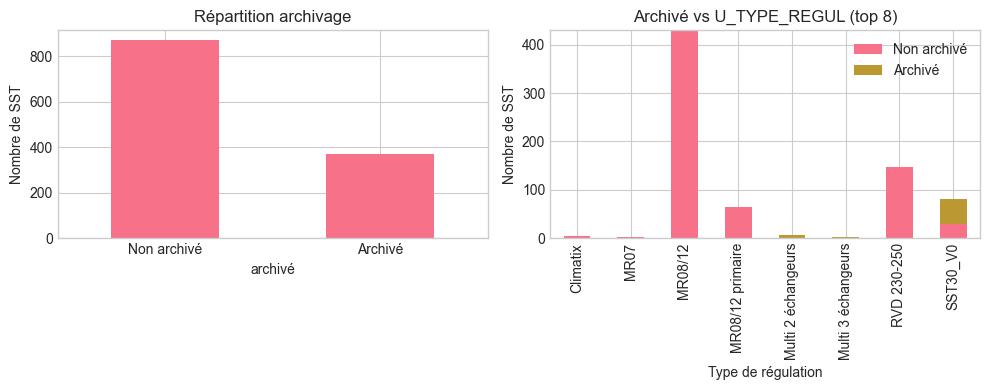

In [5]:
# %% Répartition archivé
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_sst["archivé"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_xticklabels(["Non archivé", "Archivé"], rotation=0)
axes[0].set_ylabel("Nombre de SST")
axes[0].set_title("Répartition archivage")

pd.crosstab(df_sst["archivé"], df_sst["U_TYPE_REGUL"].fillna("_MANQUANT_")).iloc[:, :8].T.plot(kind="bar", stacked=True, ax=axes[1], legend=True)
axes[1].set_xlabel("Type de régulation")
axes[1].set_ylabel("Nombre de SST")
axes[1].set_title("Archivé vs U_TYPE_REGUL (top 8)")
axes[1].legend(["Non archivé", "Archivé"])
plt.tight_layout()
plt.show()

### 2.2 U_TYPE_REGUL, U_PROD_ECS, U_PUISSANCE

In [6]:
# %% Parsing U_PUISSANCE
def parse_puissance(s):
    if pd.isna(s): return np.nan
    m = re.search(r"([\d.]+)\s*k?W", str(s), re.I)
    return float(m.group(1)) if m else np.nan

df_sst["U_PUISSANCE_kW"] = df_sst["U_PUISSANCE"].apply(parse_puissance)
print("Statistiques U_PUISSANCE (kW) :")
print(df_sst["U_PUISSANCE_kW"].describe())
print(f"\nArchivé vs non archivé - médiane puissance :")
print(df_sst.groupby("archivé")["U_PUISSANCE_kW"].median())

Statistiques U_PUISSANCE (kW) :
count    1238.000000
mean       67.882876
std       114.203537
min         5.000000
25%        15.000000
50%        40.000000
75%        85.000000
max      2500.000000
Name: U_PUISSANCE_kW, dtype: float64

Archivé vs non archivé - médiane puissance :
archivé
0    40.0
1    40.0
Name: U_PUISSANCE_kW, dtype: float64


## 3. Préparation pour le clustering GESA

Préparation des colonnes nécessaires aux règles GESA :
- **U_PUISSANCE_kW_fill** : puissance en kW (NaN → médiane)
- **U_PROD_ECS_01** : 0 ou 1 (NaN/-1 → 0 pour SST remontées)
- **archivé** : 1 si U_NO_EGID dans le parquet, 0 sinon

In [7]:
# %% Préparation du DataFrame pour clustering GESA
df_cluster = df_sst[["U_NO_EGID", "U_TYPE_REGUL", "U_PROD_ECS", "U_PUISSANCE_kW", "archivé"]].copy()

df_cluster["U_TYPE_REGUL"] = df_cluster["U_TYPE_REGUL"].fillna("_MANQUANT_")
df_cluster["U_PROD_ECS"] = df_cluster["U_PROD_ECS"].fillna(-1).astype(str)

# U_PROD_ECS_01 : 0 ou 1 (NaN/-1 → 0 pour les règles GESA)
def map_ecs_01(x):
    s = str(x).strip()
    if s in ("1", "1.0"): return 1
    return 0  # 0, 0.0, -1, NaN → 0
df_cluster["U_PROD_ECS_01"] = df_cluster["U_PROD_ECS"].apply(map_ecs_01)

med_puissance = df_cluster["U_PUISSANCE_kW"].median()
df_cluster["U_PUISSANCE_kW_fill"] = df_cluster["U_PUISSANCE_kW"].fillna(med_puissance)

# X_scaled pour la PCA (visualisation section 5)
features_pca = ["U_PUISSANCE_kW_fill", "U_PROD_ECS_01", "archivé"]
X = df_cluster[features_pca].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Colonnes préparées : U_PUISSANCE_kW_fill, U_PROD_ECS_01, archivé")
print("Shape X_scaled :", X_scaled.shape)

Colonnes préparées : U_PUISSANCE_kW_fill, U_PROD_ECS_01, archivé
Shape X_scaled : (1238, 3)


## 4. Clustering selon les règles GESA

Assignation des clusters selon les règles définies dans `Clustering_rules.md`.

In [8]:
# %% Assignation des clusters selon les règles GESA
# SST non remontées (archivé=0) : cluster 1 ou 2 selon U_PUISSANCE
# SST remontées (archivé=1) : cluster 3, 4, 5 ou 6 selon U_PUISSANCE et U_PROD_ECS

def assign_cluster_gesa(row):
    p = row["U_PUISSANCE_kW_fill"]
    ecs = row["U_PROD_ECS_01"]
    arch = row["archivé"]
    if arch == 0:  # SST non remontées (SST2.0)
        return 1 if p < 100 else 2
    # SST remontées (SST3.0 & SST3.1)
    if p < 100 and ecs == 0: return 3
    if p >= 100 and ecs == 0: return 4
    if p < 100 and ecs == 1: return 5
    return 6  # p >= 100 and ecs == 1

df_cluster["cluster"] = df_cluster.apply(assign_cluster_gesa, axis=1)
n_clusters = 6

print(f"Répartition des {n_clusters} clusters (règles GESA) :")
print(df_cluster["cluster"].value_counts().sort_index())


Répartition des 6 clusters (règles GESA) :
cluster
1    682
2    187
3     51
4     37
5    246
6     35
Name: count, dtype: int64


## 5. Analyse des clusters

Profil de chaque cluster : U_TYPE_REGUL, U_PROD_ECS, U_PUISSANCE, **archivé**

In [9]:
# %% Profil des clusters
for c in sorted(df_cluster["cluster"].unique()):
    subset = df_cluster[df_cluster["cluster"] == c]
    pct_arch = subset["archivé"].mean() * 100
    print(f"\n--- Cluster {c} ({len(subset)} SST, {pct_arch:.0f}% archivées) ---")
    print("  U_TYPE_REGUL (top 3) :", subset["U_TYPE_REGUL"].value_counts().head(3).to_dict())
    print("  U_PROD_ECS :", subset["U_PROD_ECS"].value_counts().to_dict())
    print("  U_PUISSANCE_kW : min={:.0f}, max={:.0f}, médiane={:.0f}".format(
        subset["U_PUISSANCE_kW"].min(), subset["U_PUISSANCE_kW"].max(), subset["U_PUISSANCE_kW"].median()
    ))


--- Cluster 1 (682 SST, 0% archivées) ---
  U_TYPE_REGUL (top 3) : {'MR08/12': 336, 'SST30_V1': 135, 'RVD 230-250': 126}
  U_PROD_ECS : {'-1.0': 491, '1.0': 160, '0.0': 31}
  U_PUISSANCE_kW : min=5, max=90, médiane=25

--- Cluster 2 (187 SST, 0% archivées) ---
  U_TYPE_REGUL (top 3) : {'MR08/12': 94, 'MR08/12 primaire': 28, 'RVD 230-250': 22}
  U_PROD_ECS : {'-1.0': 146, '0.0': 30, '1.0': 11}
  U_PUISSANCE_kW : min=100, max=2500, médiane=140

--- Cluster 3 (51 SST, 100% archivées) ---
  U_TYPE_REGUL (top 3) : {'SST30_V0': 31, 'SST30_V1': 16, 'SST30_V3': 3}
  U_PROD_ECS : {'0.0': 51}
  U_PUISSANCE_kW : min=6, max=90, médiane=50

--- Cluster 4 (37 SST, 100% archivées) ---
  U_TYPE_REGUL (top 3) : {'SST30_V0': 20, 'Multi 2 échangeurs': 5, 'SST30_V3': 4}
  U_PROD_ECS : {'0.0': 36, '-1.0': 1}
  U_PUISSANCE_kW : min=100, max=1400, médiane=250

--- Cluster 5 (246 SST, 100% archivées) ---
  U_TYPE_REGUL (top 3) : {'SST30_V1': 203, 'SST31_V61': 19, 'SST30_V2': 18}
  U_PROD_ECS : {'1.0': 246}
 

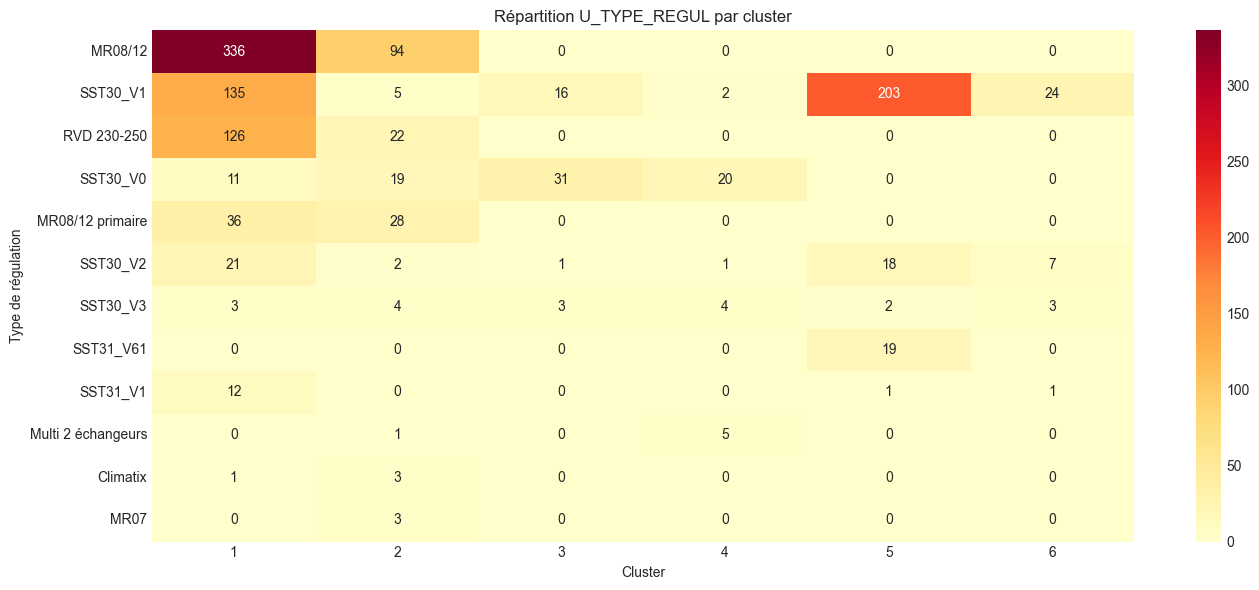

In [10]:
# %% Heatmap : répartition U_TYPE_REGUL par cluster
cross_regul = pd.crosstab(df_cluster["cluster"], df_cluster["U_TYPE_REGUL"])
top_types = [c for c in df_cluster["U_TYPE_REGUL"].value_counts().head(12).index if c in cross_regul.columns]
cross_regul_top = cross_regul[top_types] if top_types else cross_regul.iloc[:, :12]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cross_regul_top.T, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_xlabel("Cluster")
ax.set_ylabel("Type de régulation")
ax.set_title("Répartition U_TYPE_REGUL par cluster")
plt.tight_layout()
plt.show()

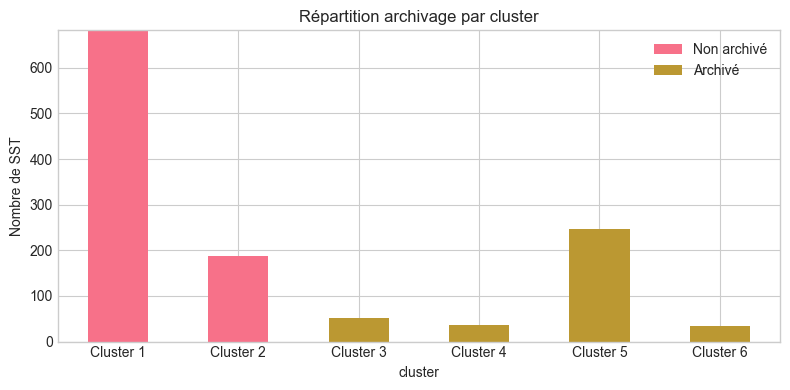

In [14]:

# Graphique archivé vs non archivé par cluster
fig, ax = plt.subplots(figsize=(8, 4))
pd.crosstab(df_cluster["cluster"], df_cluster["archivé"]).plot(kind="bar", ax=ax, stacked=True)
ax.set_xticklabels([f"Cluster {i}" for i in sorted(df_cluster["cluster"].unique())], rotation=0)
ax.set_ylabel("Nombre de SST")
ax.legend(["Non archivé", "Archivé"])
ax.set_title("Répartition archivage par cluster")
plt.tight_layout()
plt.show()

## 5.1 Détail des installations archivées (SST remontées)

Analyse spécifique des SST avec mesures archivées (présentes dans le DF LYNX) :
- **Part avec ECS** : proportion d'installations disposant d'eau chaude sanitaire (U_PROD_ECS = 1)
- **Part > 100 kW** : proportion d'installations de puissance supérieure à 100 kW

=== Installations archivées (SST remontées) ===

Total : 369 installations

Part avec ECS (U_PROD_ECS=1)     :  281 (76.2 %)
Part sans ECS (U_PROD_ECS=0)     :   88 (23.8 %)

Part > 100 kW                    :   72 (19.5 %)
Part ≤ 100 kW                    :  297 (80.5 %)

Répartition croisée (ECS × Puissance) :
U_PUISSANCE_kW_fill  > 100 kW  ≤ 100 kW
U_PROD_ECS_01                          
Avec ECS                   35       246
Sans ECS                   37        51


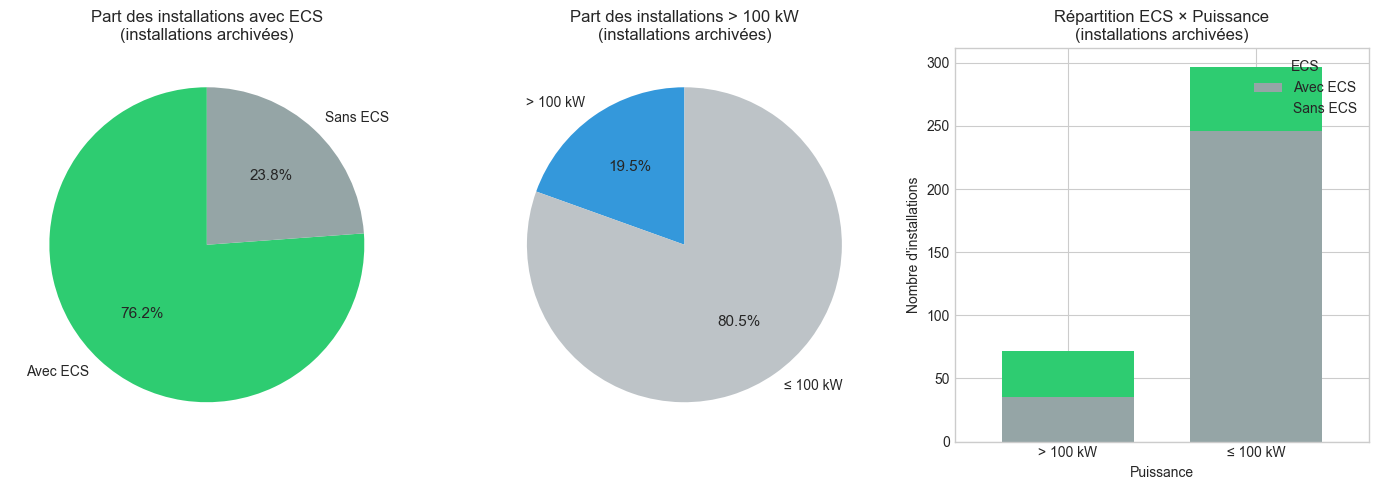


Graphique exporté : 0_Data\1_Structured\rapport_installations_archivees.png


In [12]:
# %% Installations archivées : statistiques et graphiques pour rapport
df_arch = df_cluster[df_cluster["archivé"] == 1].copy()
n_arch = len(df_arch)

# Statistiques
n_ecs = (df_arch["U_PROD_ECS_01"] == 1).sum()
n_gt100 = (df_arch["U_PUISSANCE_kW_fill"] >= 100).sum()
pct_ecs = n_ecs / n_arch * 100 if n_arch > 0 else 0
pct_gt100 = n_gt100 / n_arch * 100 if n_arch > 0 else 0

print("=== Installations archivées (SST remontées) ===\n")
print(f"Total : {n_arch} installations\n")
print(f"Part avec ECS (U_PROD_ECS=1)     : {n_ecs:4d} ({pct_ecs:.1f} %)")
print(f"Part sans ECS (U_PROD_ECS=0)     : {n_arch - n_ecs:4d} ({100 - pct_ecs:.1f} %)\n")
print(f"Part > 100 kW                    : {n_gt100:4d} ({pct_gt100:.1f} %)")
print(f"Part ≤ 100 kW                    : {n_arch - n_gt100:4d} ({100 - pct_gt100:.1f} %)")

# Tableau croisé ECS x Puissance
cross = pd.crosstab(
    df_arch["U_PROD_ECS_01"].map({0: "Sans ECS", 1: "Avec ECS"}),
    (df_arch["U_PUISSANCE_kW_fill"] >= 100).map({False: "≤ 100 kW", True: "> 100 kW"})
)
print("\nRépartition croisée (ECS × Puissance) :")
print(cross)

# --- Graphiques pour rapport (haute résolution) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. Part ECS
ax = axes[0]
labels_ecs = ["Avec ECS", "Sans ECS"]
sizes_ecs = [n_ecs, n_arch - n_ecs]
colors_ecs = ["#2ecc71", "#95a5a6"]
wedges, texts, autotexts = ax.pie(sizes_ecs, labels=labels_ecs, autopct="%1.1f%%", colors=colors_ecs, startangle=90)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title("Part des installations avec ECS\n(installations archivées)", fontsize=12)

# 2. Part > 100 kW
ax = axes[1]
labels_puiss = ["> 100 kW", "≤ 100 kW"]
sizes_puiss = [n_gt100, n_arch - n_gt100]
colors_puiss = ["#3498db", "#bdc3c7"]
wedges, texts, autotexts = ax.pie(sizes_puiss, labels=labels_puiss, autopct="%1.1f%%", colors=colors_puiss, startangle=90)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title("Part des installations > 100 kW\n(installations archivées)", fontsize=12)

# 3. Répartition croisée (barres empilées)
ax = axes[2]
cross_plot = cross.T  # Puissance en lignes, ECS en colonnes
cross_plot.plot(kind="bar", stacked=True, ax=ax, color=["#95a5a6", "#2ecc71"], width=0.7)
ax.set_xlabel("Puissance")
ax.set_ylabel("Nombre d'installations")
ax.set_title("Répartition ECS × Puissance\n(installations archivées)", fontsize=12)
ax.legend(title="ECS", loc="upper right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
out_fig = Path("0_Data/1_Structured/rapport_installations_archivees.png")
out_fig.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nGraphique exporté : {out_fig}")

## 6. Export

In [13]:
# %% Export
out_path = Path("0_Data/1_Structured/sst_avec_clusters_GESA.parquet")
df_export = df_sst.merge(
    df_cluster[["U_NO_EGID", "cluster"]],
    on="U_NO_EGID",
    how="inner"
)
# Colonnes object avec types mixtes (ex. NAME_NUMMER: int + 'aucun') -> string pour Parquet
for col in df_export.select_dtypes(include=["object"]).columns:
    df_export[col] = df_export[col].astype(str)
df_export.to_parquet(out_path, index=False)
print(f"Exporté : {out_path} ({len(df_export)} lignes)")
df_export[["U_NO_EGID", "U_TYPE_REGUL", "U_PROD_ECS", "U_PUISSANCE", "archivé", "cluster"]].head(10)

Exporté : 0_Data\1_Structured\sst_avec_clusters_GESA.parquet (1240 lignes)


C:\Users\luandrey\AppData\Local\Temp\ipykernel_45496\2566176879.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_export.select_dtypes(include=["object"]).columns:


,U_NO_EGID,U_TYPE_REGUL,U_PROD_ECS,U_PUISSANCE,archivé,cluster
0,190507988,RVD 230-250,NaN,7kW,0,1
1,235557415,RVD 230-250,NaN,7kW,0,1
2,190210251,RVD 230-250,NaN,7kW,0,1
3,235557377,RVD 230-250,NaN,8kW,0,1
4,3091203,MR08/12,NaN,180kW,0,2
5,1511281,MR08/12,NaN,70kW,0,1
6,235556801,RVD 230-250,NaN,8kW,0,1
7,1511243,MR08/12,NaN,45kW,0,1
8,1511242,MR08/12,NaN,40kW,0,1
9,1511427,RVD 230-250,NaN,170kW,0,2
